In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)
print(f"Rindu skaits: {df.shape[0]}")
print(f"Kolonnu skaits: {df.shape[1]}")
df.head()


Rindu skaits: 12330
Kolonnu skaits: 18


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
# Datu tipi un trūkstošās vērtības
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [4]:
# Skaitlisko kolonnu statistika
df.describe()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [5]:
# Trūkstošo vērtību skaits pa kolonnām
df.isnull().sum()


Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [6]:
# Target mainīgā sadalījums
print(df['Revenue'].value_counts())
print(f"\nPirkumu veikušo sesiju īpatsvars: {df['Revenue'].mean():.1%}")


Revenue
False    10422
True      1908
Name: count, dtype: int64

Pirkumu veikušo sesiju īpatsvars: 15.5%


1. Datu kopā ir 12330 rindas un 18 kolonnas.

2. Skaitliskās kolonnas ir: Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues un SpecialDay.

Kategoriskās kolonnas ir: Month, OperatingSystems, Browser, Region, TrafficType, VisitorType, Weekend un Revenue.

3. Trūkstošo vērtību nav nevienā kolonnā.

4. Ar pirkumu beidzās apmēram 15.47% sesiju.


## 2. uzdevums. Apstrādā trūkstošās vērtības

### 2.1. Identificē trūkstošās vērtības


In [7]:
# Trūkstošo vērtību vizualizācija
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    plt.figure(figsize=(8, 4))
    missing.plot(kind='bar', color='coral')
    plt.title('Trūkstošās vērtības pa kolonnām')
    plt.ylabel('Skaits')
    plt.tight_layout()
    plt.show()
else:
    print('Datu kopā nav trūkstošu vērtību.')


Datu kopā nav trūkstošu vērtību.


### 2.2. Aizpildi trūkstošās vērtības

Šajā datu kopā nevienā kolonnā nav trūkstošu vērtību, tāpēc aizpildīšana ar mediānu, vidējo, modu vai dzēšana nav nepieciešama.


In [8]:
# Pārbaudi, vai trūkstošās vērtības ir aizpildītas
print("Trūkstošās vērtības pēc apstrādes:")
print(df.isnull().sum().sum())


Trūkstošās vērtības pēc apstrādes:
0


### 2.3. Pārbaude


In [9]:
# Galīgā pārbaude — nedrīkst būt nevienas trūkstošās vērtības
assert df.isnull().sum().sum() == 0, "Vēl ir trūkstošas vērtības!"
print("✓ Visas trūkstošās vērtības ir apstrādātas.")


✓ Visas trūkstošās vērtības ir apstrādātas.


## 3. uzdevums. Normalizē skaitliskās kolonnas

Šajā daļā tiek normalizētas izvēlētās skaitliskās kolonnas ar `StandardScaler`, lai to vērtību skalas būtu salīdzināmas.


### 3.1. Izvēlies kolonnas normalizēšanai

Normalizēšanai izvēlētas kolonnas ar atšķirīgām vērtību skalām, piemēram, ilguma kolonnas ar lielākām vērtībām un likmju kolonnas ar mazākām vērtībām.


In [10]:
from sklearn.preprocessing import StandardScaler

# Izvēlētās skaitliskās kolonnas normalizēšanai
numeric_cols = [
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues'
]

# Saglabājam datus pirms normalizācijas, lai var salīdzināt grafikos
before_normalization = df[numeric_cols].copy()

print('PIRMS normalizācijas:')
print(df[numeric_cols].describe().round(2))


PIRMS normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                     80.82                   34.47   
std                     176.78                  140.75   
min                       0.00                    0.00   
25%                       0.00                    0.00   
50%                       7.50                    0.00   
75%                      93.26                    0.00   
max                    3398.75                 2549.38   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                   1194.75         0.02       0.04        5.89  
std                    1913.67         0.05       0.05       18.57  
min                       0.00         0.00       0.00        0.00  
25%                     184.14         0.00       0.01        0.00  
50%                     598.94         0.

### 3.2. Piemēro StandardScaler


In [11]:
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print('\nPĒC normalizācijas:')
print(df[numeric_cols].describe().round(2))



PĒC normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                      0.00                   -0.00   
std                       1.00                    1.00   
min                      -0.46                   -0.24   
25%                      -0.46                   -0.24   
50%                      -0.41                   -0.24   
75%                       0.07                   -0.24   
max                      18.77                   17.87   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                     -0.00        -0.00       0.00        0.00  
std                       1.00         1.00       1.00        1.00  
min                      -0.62        -0.46      -0.89       -0.32  
25%                      -0.53        -0.46      -0.59       -0.32  
50%                      -0.31        -0.3

### 3.3. Vizualizē rezultātu


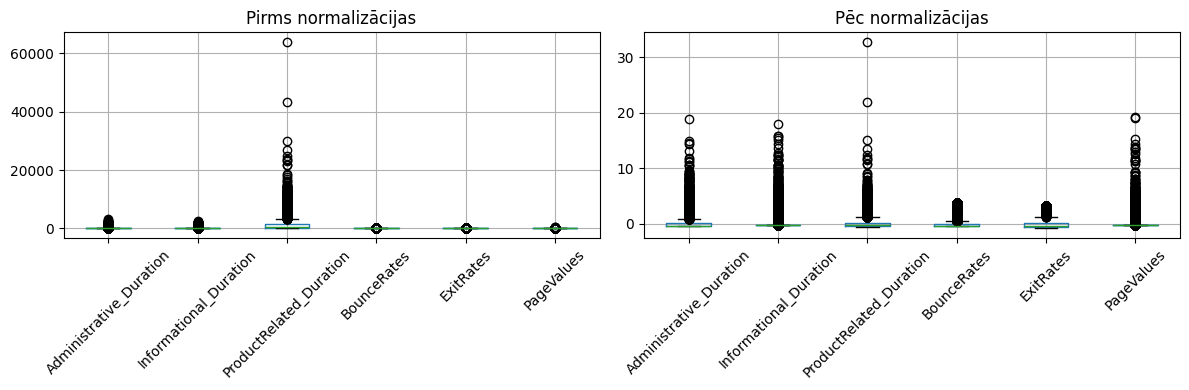

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pirms normalizācijas
before_normalization.boxplot(ax=axes[0])
axes[0].set_title('Pirms normalizācijas')
axes[0].tick_params(axis='x', rotation=45)

# Pēc normalizācijas
df[numeric_cols].boxplot(ax=axes[1])
axes[1].set_title('Pēc normalizācijas')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 4. uzdevums. Kodē kategoriskos mainīgos


### 4.1. Identificē kategoriskās kolonnas

Šajā solī tiek atrastas kolonnas ar `object` un `bool` datu tipu, lai noteiktu, kurām vajadzīga kodēšana.


In [13]:
# Kuras kolonnas ir kategoriskas?
cat_cols = df.select_dtypes(include=['object', 'string', 'bool']).columns.tolist()
print('Kategoriskās kolonnas:', cat_cols)

for col in cat_cols:
    print(f'\n{col}: {df[col].unique()}')


Kategoriskās kolonnas: ['Month', 'VisitorType', 'Weekend', 'Revenue']

Month: <StringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str

VisitorType: <StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str

Weekend: [False  True]

Revenue: [False  True]


### 4.2. Piemēro kodēšanu

Kolonnām `Weekend` un `Revenue` tika izvēlēta pārveidošana uz `0/1`, jo tām ir tikai divas iespējamās vērtības (`True` un `False`). Šādā gadījumā papildu dummy kolonnas nav vajadzīgas, jo viena bināra vērtība pilnībā apraksta šo informāciju.

Kolonnām `Month` un `VisitorType` tika izvēlēts `One-Hot Encoding`, jo šīm kolonnām ir vairākas atšķirīgas kategorijas. Šī metode izveido atsevišķu kolonnu katrai kategorijai un ir piemērota, jo starp kategoriju nosaukumiem nav dabiskas skaitliskas secības.


In [14]:
from sklearn.preprocessing import LabelEncoder

# Boolean kolonnas — pārvērš uz 0/1
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

# One-Hot Encoding kategoriskām kolonnām
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True, dtype=int)

print(f'Kolonnu skaits pēc kodēšanas: {df.shape[1]}')
df.head()


Kolonnu skaits pēc kodēšanas: 27


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,-0.457191,0,-0.244931,1,-0.624348,3.667189,3.229316,-0.317178,0.0,...,1,0,0,0,0,0,0,0,0,1
1,0,-0.457191,0,-0.244931,2,-0.590903,-0.457683,1.171473,-0.317178,0.0,...,1,0,0,0,0,0,0,0,0,1
2,0,-0.457191,0,-0.244931,1,-0.624348,3.667189,3.229316,-0.317178,0.0,...,1,0,0,0,0,0,0,0,0,1
3,0,-0.457191,0,-0.244931,2,-0.622954,0.573535,1.994610,-0.317178,0.0,...,1,0,0,0,0,0,0,0,0,1
4,0,-0.457191,0,-0.244931,10,-0.296430,-0.045196,0.142551,-0.317178,0.0,...,1,0,0,0,0,0,0,0,0,1


### 4.3. Pārbaude


In [15]:
# Pārliecinies, ka nav palikušas 'object' tipa kolonnas
remaining_objects = df.select_dtypes(include=['object', 'string', 'bool']).columns.tolist()
print(f'Atlikušās kategoriskās kolonnas: {remaining_objects}')
assert len(remaining_objects) == 0, 'Vēl ir neapstrādātas kategoriskas kolonnas!'
print('✓ Visas kategoriskās kolonnas ir kodētas.')


Atlikušās kategoriskās kolonnas: []
✓ Visas kategoriskās kolonnas ir kodētas.


## 5. uzdevums. Izveido jaunu iezīmi (Feature Engineering)


### 5.1. Jauna feature izveide

Tiek izveidota jauna iezīme `TotalDuration`, kas apvieno trīs vietnē pavadītā laika kolonnas.


In [16]:
# Kopējais laiks vietnē
df['TotalDuration'] = (
    df['Administrative_Duration']
    + df['Informational_Duration']
    + df['ProductRelated_Duration']
)

print(df[['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'TotalDuration']].head())


   Administrative_Duration  Informational_Duration  ProductRelated_Duration  \
0                -0.457191               -0.244931                -0.624348   
1                -0.457191               -0.244931                -0.590903   
2                -0.457191               -0.244931                -0.624348   
3                -0.457191               -0.244931                -0.622954   
4                -0.457191               -0.244931                -0.296430   

   TotalDuration  
0      -1.326469  
1      -1.293024  
2      -1.326469  
3      -1.325076  
4      -0.998552  


### 5.2. Paskaidro jauno feature

Jaunā iezīme `TotalDuration` parāda kopējo laiku, ko lietotājs pavadīja dažādās vietnes sadaļās vienas sesijas laikā. Biznesa kontekstā tas palīdz saprast, cik iesaistīts bija apmeklētājs. Šī iezīme var būt noderīga ML modelim, jo lietotāji, kuri vietnē pavada vairāk laika, varētu būt tuvāk pirkuma veikšanai nekā tie, kuri lapu ātri pamet.


### 5.3. Vizualizē jauno feature


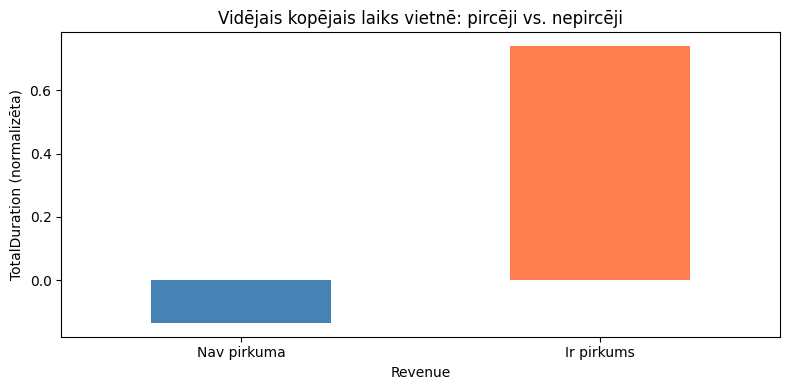

In [17]:
# Parādi, kā jaunā iezīme atšķiras starp pircējiem un nepircējiem
plt.figure(figsize=(8, 4))
df.groupby('Revenue')['TotalDuration'].mean().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Vidējais kopējais laiks vietnē: pircēji vs. nepircēji')
plt.ylabel('TotalDuration (normalizēta)')
plt.xticks([0, 1], ['Nav pirkuma', 'Ir pirkums'], rotation=0)
plt.tight_layout()
plt.show()


## 6. uzdevums. Saglabā tīru datu kopu


### 6.1. Eksportē apstrādātos datus


In [18]:
# Saglabā tīro dataset nākamajai nedēļai
df.to_csv('shoppers_clean.csv', index=False)
print(f'Saglabāts: {df.shape[0]} rindas, {df.shape[1]} kolonnas')
print("✓ Tīrā datu kopa ir saglabāta failā 'shoppers_clean.csv'")


Saglabāts: 12330 rindas, 28 kolonnas
✓ Tīrā datu kopa ir saglabāta failā 'shoppers_clean.csv'


### 6.2. Rezumējums

Šajā datu kopā netika atrastas trūkstošās vērtības, tāpēc aizpildīšana vai rindu dzēšana nebija nepieciešama. Tika normalizētas vairākas skaitliskās kolonnas, kodēti kategoriskie mainīgie un izveidota jauna iezīme `TotalDuration`. Pirms apstrādes datu kopā bija 18 kolonnas, bet pēc kategorisko kolonnu kodēšanas un jaunās iezīmes izveides to skaits palielinājās līdz 28 kolonnām.
